# **RQ1**: Number of neighbors per node over time

For each node in every snapshot, compute the node's degree and record it in a CSV file.

In [ ]:
# ego delle parole che shrinkano di più

# distr dello shrink positivo

# plotto parole che sono più soggette a effetto sh e freq




In [1]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("networks_hybrid")        
output_dir = Path("degree_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)



print("[START] Estrazione degree dai grafi igraph")

for snap in range(1, 8):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    output_csv = output_dir / f"node_degree_snap{snap}_hybrid.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    degrees = g.degree()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "degree": degrees
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


[START] Estrazione degree dai grafi igraph

[SNAPSHOT 1]
[DONE] nodi=34742, archi=3033079 in 2.93s

[SNAPSHOT 2]
[DONE] nodi=28017, archi=1985640 in 1.77s

[SNAPSHOT 3]
[DONE] nodi=28028, archi=1930980 in 1.60s

[SNAPSHOT 4]
[DONE] nodi=34431, archi=3011365 in 2.85s

[SNAPSHOT 5]
[DONE] nodi=37089, archi=3482725 in 3.42s

[SNAPSHOT 6]
[DONE] nodi=37658, archi=3604324 in 3.26s

[SNAPSHOT 7]
[DONE] nodi=31000, archi=2390413 in 2.40s

[TOTAL] Tutti i CSV generati


# Individual shrinkage Si
Compute the individual shrinkage for each node at each time step.
Use the first snapshot in which the word appears as the baseline (t0).

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

degree_dir = Path("degree_csv_igraph_snapshot")
output_csv = Path("shrinkage_i_norm.csv")

snapshots = range(1, 8)

# --- leggo tutti i degree ---
all_degrees = {}  # all_degrees[snap][token] = degree
for snap in snapshots:
    df = pd.read_csv(degree_dir / f"node_degree_snap{snap}_hybrid.csv")
    
    # Convertiamo i token in stringa e ignoriamo NaN
    df = df.dropna(subset=["token"])
    df["token"] = df["token"].astype(str)
    
    all_degrees[snap] = dict(zip(df["token"], df["degree"]))

# --- trovo primo snapshot per ogni token ---
first_snap = {}
for snap in snapshots:
    for token in all_degrees[snap]:
        if token not in first_snap:
            first_snap[token] = snap

# --- calcolo in quanti snapshot compare ogni token ---
appear_count = {token: 0 for token in first_snap}

network_stats = {} 
for snap in snapshots: 
    degrees_snap = all_degrees[snap] 
    # Calcolo su TUTTI i nodi dello snapshot (corretto per la normalizzazione) 
    mean_deg = np.mean(list(degrees_snap.values())) if degrees_snap else 1 
        
    network_stats[snap] = mean_deg 

#< --- 2. Calcolo Shrinkage --- 
shrinkage_data = {"token": tokens} 
# Inizializziamo le liste per ogni snapshot nel dizionario for snap in snapshots:
for snap in snapshots:
    shrinkage_data[f"shrinkage_snap{snap}"] = [] 
    
for token in tokens: 
    t0 = first_snap[token] 
    # Prendo il grado normalizzato al tempo t0 (Baseline) 
    # Nota: degree_raw_t0 deve esistere, altrimenti t0 non sarebbe t0 
    degree_raw_t0 = all_degrees[t0].get(token, 0) 
    norm_degree_t0 = degree_raw_t0 / network_stats[t0] 
    for snap in snapshots: 
        # Se siamo prima della nascita della parola, mettiamo NaN 
        if snap < t0: 
            s = np.nan 
        else: 
            # Grado corrente 
            degree_raw_t = all_degrees[snap].get(token, 0) 
            norm_degree_t = degree_raw_t / network_stats[snap] 
            if norm_degree_t0 == 0: 
                s = np.nan # Evita divisione per zero (caso patologico) 
            else: 
                s = 1 - (norm_degree_t / norm_degree_t0) 
            # Aggiungiamo alla colonna corretta 
        shrinkage_data[f"shrinkage_snap{snap}"].append(s)

# --- salvo CSV finale ---
df_shrink_filtered = pd.DataFrame(shrinkage_data)
df_shrink_filtered.to_csv(output_csv, index=False)

print(f"[DONE] Shrinkage calcolato per token in ≥5 snapshot in {output_csv}")


[DONE] Shrinkage calcolato per token in ≥5 snapshot in shrinkage_i_norm.csv


In [29]:
len(df_shrink_filtered)

27129

cc

In [ ]:
import pandas as pd
import igraph as ig
from pathlib import Path
import time

graph_dir = Path("networks_hybrid")        
output_dir = Path("cc_csv_igraph_snapshot")
output_dir.mkdir(exist_ok=True)



print("[START] Estrazione cc dai grafi igraph")

for snap in range(1, 8):
    t0 = time.time()

    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    output_csv = output_dir / f"node_cc_snap{snap}_hybrid.csv"

    print(f"\n[SNAPSHOT {snap}]")

    # importo g
    g = ig.Graph.Read_Pickle(graph_file)

   
    cc = g.()   # numero di vicini

   
    tokens = g.vs["token"]

    df_out = pd.DataFrame({
        "token": tokens,
        "cc": cc
    })

    df_out.to_csv(output_csv, index=False)

    print(
        f"[DONE] nodi={g.vcount()}, archi={g.ecount()} "
        f"in {time.time() - t0:.2f}s"
    )

print("\n[TOTAL] Tutti i CSV generati")


In [47]:
import pandas as pd
import numpy as np
import igraph as ig
from pathlib import Path

# =============================================================================
# CONFIGURAZIONE
# =============================================================================

# Cartella dove sono salvati i file dei grafi (es. .gml, .graphml, .pickle)
input_graphs_dir = Path("networks_hybrid_annotated") 

# Cartella output finale
output_csv = Path("semantic_shrinkage_clustering.csv")

# Range degli snapshot
snapshots = range(1, 8)

# =============================================================================
# 1. CARICAMENTO GRAFI E CALCOLO CLUSTERING
# =============================================================================
print("--- FASE 1: Caricamento Grafi e Calcolo CC ---")

all_clustering = {}      # {snap: {token: cc_value}}
network_cc_means = {}    # {snap: media_globale_cc}

for snap in snapshots:
    # ADATTA L'ESTENSIONE AL TUO FORMATO (.gml, .graphml, .pickle, etc.)
    # Se usi pickle: g = ig.Graph.Read_Pickle(graph_path)
    graph_path = input_graphs_dir / f"graph_snap{snap}_hybrid.igp"
    
    if not graph_path.exists():
        print(f"[SKIP] Grafo non trovato: {graph_path}")
        continue
        
    try:
        # Caricamento Grafo
        g = ig.Graph.Read_Pickle(graph_path) 
        
        # Opzionale: Se il grafo ha self-loops o multi-edges, semplifica per correttezza del CC
        # g = g.simplify() 
        
        # Calcolo Clustering Coefficient (Transitivity Local Undirected)
        # mode="zero": se il nodo ha grado < 2, il CC è 0 (invece di NaN)
        cc_values = g.transitivity_local_undirected(mode="zero")
        
        # Assumiamo che i nodi abbiano un attributo "name" o "label" con la parola
        # Se il tuo attributo si chiama diversamente (es. "id"), cambialo qui sotto
        node_names = g.vs["token"] 
        
        # Salviamo nel dizionario
        all_clustering[snap] = dict(zip(node_names, cc_values))
        
        # Calcolo Media Globale per Normalizzazione
        # Escludiamo eventuali nodi isolati se vuoi una media più "pura", 
        # ma matematicamente la media su tutti i nodi è corretta per lo shrinkage.
        mean_cc = np.mean(cc_values) if cc_values else 1
        network_cc_means[snap] = mean_cc
        
        print(f"Snap {snap}: Caricato (Nodi: {len(node_names)}, CC Medio: {mean_cc:.4f})")
        
    except Exception as e:
        print(f"Errore su Snap {snap}: {e}")

# =============================================================================
# 2. FILTRAGGIO TOKEN (Deve esistere in almeno N snapshot)
# =============================================================================
print("\n--- FASE 2: Filtraggio Token ---")

# Identifica il primo snapshot (t0)
first_snap = {}
for snap in snapshots:
    if snap in all_clustering:
        for token in all_clustering[snap]:
            if token not in first_snap:
                first_snap[token] = snap

# Conta apparizioni
appear_count = {token: 0 for token in first_snap}
for snap in snapshots:
    if snap in all_clustering:
        for token in first_snap:
            if token in all_clustering[snap]:
                appear_count[token] += 1

# Filtro (es. almeno 5 apparizioni)
min_appearances = 5
tokens = sorted([tok for tok, count in appear_count.items() if count >= min_appearances])
print(f"Token selezionati per l'analisi: {len(tokens)}")

# =============================================================================
# 3. CALCOLO SHRINKAGE NORMALIZZATO
# =============================================================================
print("\n--- FASE 3: Calcolo Shrinkage ---")

shrinkage_data = {"token": tokens}

for snap in snapshots:
    shrink_values = []
    
    # Media CC della rete corrente (Denominatore inflazione)
    mean_cc_current = network_cc_means.get(snap, 1)
    
    for token in tokens:
        t0 = first_snap[token]
        
        # Se lo snapshot è precedente alla nascita -> NaN
        if snap < t0:
            shrink_values.append(np.nan)
            continue
        
        # Dati Baseline (t0)
        mean_cc_t0 = network_cc_means.get(t0, 1)
        raw_cc_t0 = all_clustering[t0].get(token, 0)
        
        # Dati Correnti (t)
        raw_cc_t = all_clustering.get(snap, {}).get(token, 0)
        
        # Normalizzazione
        norm_cc_t0 = raw_cc_t0 / mean_cc_t0 if mean_cc_t0 > 0 else 0
        norm_cc_t  = raw_cc_t / mean_cc_current if mean_cc_current > 0 else 0
        
        # Calcolo Shrinkage S
        # Se norm_cc_t0 è 0, non possiamo calcolare la variazione percentuale.
        # Caso tipico: parola nata come "stella" (CC=0).
        if norm_cc_t0 == 0:
            s = np.nan 
        else:
            s = 1 - (norm_cc_t / norm_cc_t0)
            
        shrink_values.append(s)
    
    shrinkage_data[f"shrinkage_snap{snap}"] = shrink_values

# =============================================================================
# 4. SALVATAGGIO
# =============================================================================
df_final = pd.DataFrame(shrinkage_data)
df_final.to_csv(output_csv, index=False)
print(f"[DONE] File salvato in: {output_csv}")



--- FASE 1: Caricamento Grafi e Calcolo CC ---
Snap 1: Caricato (Nodi: 34742, CC Medio: 0.3262)
Snap 2: Caricato (Nodi: 28017, CC Medio: 0.3037)
Snap 3: Caricato (Nodi: 28028, CC Medio: 0.2943)
Snap 4: Caricato (Nodi: 34431, CC Medio: 0.2914)
Snap 5: Caricato (Nodi: 37089, CC Medio: 0.2895)
Snap 6: Caricato (Nodi: 37658, CC Medio: 0.2890)
Snap 7: Caricato (Nodi: 31000, CC Medio: 0.2853)

--- FASE 2: Filtraggio Token ---
Token selezionati per l'analisi: 27144

--- FASE 3: Calcolo Shrinkage ---
[DONE] File salvato in: semantic_shrinkage_clustering.csv


# S_aggr
Compute the aggregated shrinkage for each node.

In [ ]:
import pandas as pd
from pathlib import Path
import numpy as np

# CSV shrinkage
shrink_csv = "shrinkage_i_norm.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # filtra solo token presenti nello shrinkage
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]

    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineamento finale
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# inizializzazione vettoriale
numeratore = pd.Series(0.0, index=df_all.index)
denominatore = pd.Series(0.0, index=df_all.index)

for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"

    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato (evita divisione per zero)
df_all["S_aggregato"] = np.where(
    denominatore > 0,
    numeratore / denominatore,
    np.nan
)

df_result = df_all[["token", "S_aggregato"]]
df_result.to_csv("shrinkage_aggr_filtered_norm.csv", index=False)

print(df_result.head())


     token  S_aggregato
0      -l'     0.731517
1     aalà     0.788523
2    abaco     0.605720
3  abanese     0.171833
4    abare     0.774292


In [48]:
import pandas as pd
from pathlib import Path
import numpy as np

# CSV shrinkage
shrink_csv = "semantic_shrinkage_clustering.csv"
df_shrink = pd.read_csv(shrink_csv)

snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

# df delle frequenze per tutti gli snapshot
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    # filtra solo token presenti nello shrinkage
    df_freq = df_freq[df_freq["token"].isin(df_shrink["token"])]

    freq_dfs.append(df_freq)

# Merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# allineamento finale
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# inizializzazione vettoriale
numeratore = pd.Series(0.0, index=df_all.index)
denominatore = pd.Series(0.0, index=df_all.index)

for snap in snapshots:
    s_col = f"shrinkage_snap{snap}"
    w_col = f"freq_snap{snap}"

    numeratore += df_all[s_col].fillna(0) * df_all[w_col].fillna(0)
    denominatore += df_all[w_col].fillna(0)

# S_aggregato (evita divisione per zero)
df_all["S_aggregato"] = np.where(
    denominatore > 0,
    numeratore / denominatore,
    np.nan
)

df_result = df_all[["token", "S_aggregato"]]
df_result.to_csv("shrinkage_aggr_cc.csv", index=False)

print(df_result.head())


     token  S_aggregato
0      -l'    -0.480577
1     aalà    -0.867658
2    abaco    -0.488352
3  abanese     0.114195
4    abare    -0.922853


In [49]:
len(df_result)

27144

Describe S_aggr

In [50]:
import pandas as pd

df = pd.read_csv("shrinkage_aggr_cc.csv")

df["S_aggregato"].describe()


count    27144.000000
mean        -0.078678
std          0.365922
min         -7.878162
25%         -0.205005
50%         -0.012225
75%          0.131794
max          0.930625
Name: S_aggregato, dtype: float64

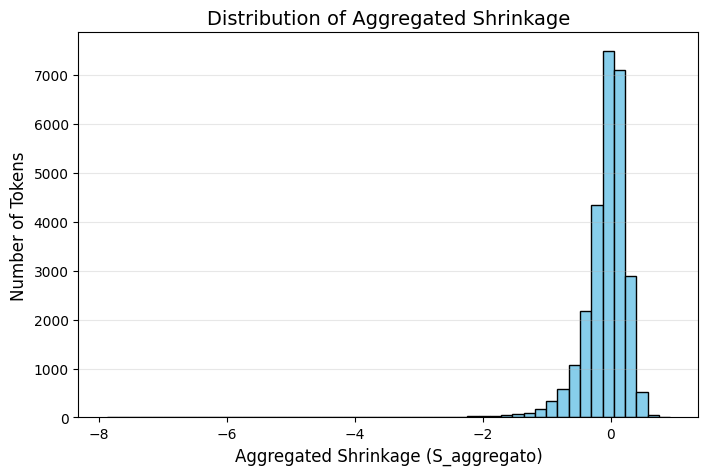

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["S_aggregato"].dropna(), bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Aggregated Shrinkage (S_aggregato)", fontsize=12)
plt.ylabel("Number of Tokens", fontsize=12)
plt.title("Distribution of Aggregated Shrinkage", fontsize=14)
plt.grid(axis='y', alpha=0.3)
plt.show()


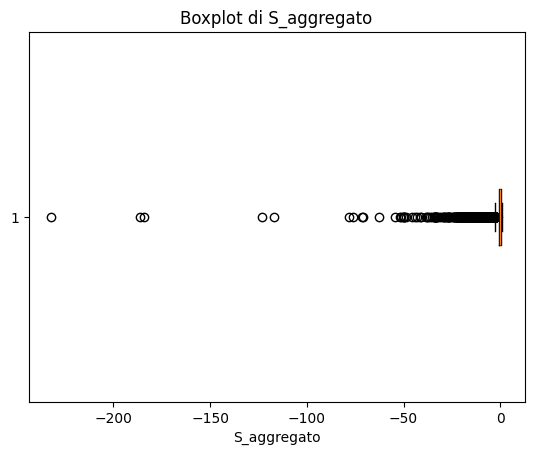

In [8]:
plt.figure()
plt.boxplot(df["S_aggregato"].dropna(), vert=False)
plt.xlabel("S_aggregato")
plt.title("Boxplot di S_aggregato")
plt.show()


In [52]:
df["class"] = "neutral"
df.loc[df["S_aggregato"] > 0, "class"] = "shrinkage"
df.loc[df["S_aggregato"] < 0, "class"] = "expansion"

df["class"].value_counts(normalize=True) * 100


class
expansion    52.085175
shrinkage    47.417477
neutral       0.497347
Name: proportion, dtype: float64

In [53]:
# top parole con espansione forte
df.sort_values("S_aggregato", ascending=True).head(20)

,token,S_aggregato,class
9306,erminio,-7.878162,expansion
5817,comma,-6.812352,expansion
26749,vigore,-6.431563,expansion
15714,mir,-5.219621,expansion
3828,bossi,-5.202188,expansion
4399,caneo,-5.051536,expansion
15206,massonico,-4.965984,expansion
25428,tonco,-4.741308,expansion
910,aldilà,-4.729580,expansion
9938,fassa,-4.392279,expansion


In [54]:
# top parole con shrinkage forte
df.sort_values("S_aggregato", ascending=False).head(20)

,token,S_aggregato,class
11878,iceberg,0.930625,shrinkage
4062,buna,0.837543,shrinkage
20500,resa,0.790216,shrinkage
24644,super,0.776152,shrinkage
24173,staff,0.743852,shrinkage
19729,puma,0.723938,shrinkage
20417,relax,0.713842,shrinkage
16706,novità,0.711508,shrinkage
23886,spazio,0.707382,shrinkage
22014,sap,0.705575,shrinkage


# RQ1
Analysis of the relationship between semantic shrinkage and token frequency variation

Objective: Check if an increase in token frequency over time is associated with greater semantic neighborhood shrinkage.

Specifically: P(Shrinkage | ΔF > 0) > P(Shrinkage | ΔF ≤ 0)

Si (degree) e Delta frequenze

In [1]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("shrinkage_i_norm.csv")

# --- frequenze ---
snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(f)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    freq_dfs.append(df_freq)

# merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")


In [2]:
import pandas as pd
import scipy.stats as stats

# --- calcolo ΔF_positive per ogni snapshot ---
snapshots = range(1, 7)  # 1..6 perché confrontiamo snap t con t+1
rows = []

for snap in snapshots:
    # shrinkage
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    # frequenze snapshot t e t+1
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t
    delta_F_positive = delta_F > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si_positive,
        "delta_F_positive": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- tabella di contingenza normale per vedere base-rate ---
ct = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"], normalize="index")
print("Tabella condizionata ΔF → Shrinkage:")
print(ct)

# --- probabilità condizionata ---
p_shrink_given_increase = df_sign.loc[df_sign["delta_F_positive"], "Si_positive"].mean()
p_shrink_given_no_increase = df_sign.loc[~df_sign["delta_F_positive"], "Si_positive"].mean()

print("\nP(Shrinkage | ΔF > 0):", p_shrink_given_increase)
print("P(Shrinkage | ΔF ≤ 0):", p_shrink_given_no_increase)
print("Difference:", p_shrink_given_increase - p_shrink_given_no_increase)

# --- base-rate (marginale) ---
p_shrink = df_sign["Si_positive"].mean()
print("P(Shrinkage) (base-rate):", p_shrink)

# --- lift / controllo bias ---
lift = p_shrink_given_increase / p_shrink
relative_risk = p_shrink_given_increase / p_shrink_given_no_increase

print("Lift (ΔF>0 vs baseline):", lift)
print("Relative Risk (ΔF>0 vs ΔF≤0):", relative_risk)

# --- Odds Ratio opzionale ---
odds_inc = p_shrink_given_increase / (1 - p_shrink_given_increase)
odds_no_inc = p_shrink_given_no_increase / (1 - p_shrink_given_no_increase)
odds_ratio = odds_inc / odds_no_inc
print("Odds Ratio (ΔF>0 vs ΔF≤0):", odds_ratio)

# --- chi2 test per associazione ---
ct_raw = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
print("\nChi2:", chi2)
print("p-value:", p_value)


Tabella condizionata ΔF → Shrinkage:
Si_positive          False     True 
delta_F_positive                    
False             0.859840  0.140160
True              0.743659  0.256341

P(Shrinkage | ΔF > 0): 0.25634057136539934
P(Shrinkage | ΔF ≤ 0): 0.14015977112037928
Difference: 0.11618080024502006
P(Shrinkage) (base-rate): 0.1801355446511215
Lift (ΔF>0 vs baseline): 1.4230426974413537
Relative Risk (ΔF>0 vs ΔF≤0): 1.8289168804737534
Odds Ratio (ΔF>0 vs ΔF≤0): 2.114645829201265

Chi2: 6506.416018335592
p-value: 0.0


In [3]:
import pandas as pd
import scipy.stats as stats

# --- costruzione dataframe dei segni ---
snapshots = range(1, 7)
rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F_positive = (F_t1 - F_t) > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "shrink": Si_positive,
        "delta_F": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- probabilità marginali ---
p_delta_pos = (df_sign["delta_F"] == True).mean()
p_delta_neg = (df_sign["delta_F"] == False).mean()

p_shrink_pos = (df_sign["shrink"] == True).mean()
p_shrink_neg = (df_sign["shrink"] == False).mean()

# --- probabilità congiunte ---
p = {}
for d in [True, False]:
    for s in [True, False]:
        p[(d, s)] = ((df_sign["delta_F"] == d) & (df_sign["shrink"] == s)).mean()

# --- lift per tutte e 4 le celle ---
lift = {
    "ΔF>0 & Shrink":     p[(True,  True)]  / (p_delta_pos * p_shrink_pos),
    "ΔF>0 & NoShrink":   p[(True,  False)] / (p_delta_pos * p_shrink_neg),
    "ΔF≤0 & Shrink":    p[(False, True)]  / (p_delta_neg * p_shrink_pos),
    "ΔF≤0 & NoShrink":  p[(False, False)] / (p_delta_neg * p_shrink_neg),
}

print("=== LIFT (tutte le 4 combinazioni) ===")
for k, v in lift.items():
    print(f"{k:20s}: {v:.4f}")


=== LIFT (tutte le 4 combinazioni) ===
ΔF>0 & Shrink       : 1.4230
ΔF>0 & NoShrink     : 0.9071
ΔF≤0 & Shrink       : 0.7781
ΔF≤0 & NoShrink     : 1.0488


Si (cc) e Delta Freq

In [68]:
import pandas as pd
from pathlib import Path

# --- shrinkage ---
df_shrink = pd.read_csv("semantic_shrinkage_clustering.csv")

# --- frequenze ---
snapshots = range(1, 8)
freq_dir = Path("../embedding/frequencies_all")

freq_dfs = []
for snap in snapshots:
    f = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(f)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    freq_dfs.append(df_freq)

# merge di tutte le frequenze
df_freq_all = freq_dfs[0]
for df in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df, on="token", how="outer")

# --- merge finale ---
df_all = df_shrink.merge(df_freq_all, on="token", how="outer")

import pandas as pd
import scipy.stats as stats

# --- calcolo ΔF_positive per ogni snapshot ---
snapshots = range(1, 7)  # 1..6 perché confrontiamo snap t con t+1
rows = []

for snap in snapshots:
    # shrinkage
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    # frequenze snapshot t e t+1
    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F = F_t1 - F_t
    delta_F_positive = delta_F > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "Si_positive": Si_positive,
        "delta_F_positive": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- tabella di contingenza normale per vedere base-rate ---
ct = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"], normalize="index")
print("Tabella condizionata ΔF → Shrinkage:")
print(ct)

# --- probabilità condizionata ---
p_shrink_given_increase = df_sign.loc[df_sign["delta_F_positive"], "Si_positive"].mean()
p_shrink_given_no_increase = df_sign.loc[~df_sign["delta_F_positive"], "Si_positive"].mean()

print("\nP(Shrinkage | ΔF > 0):", p_shrink_given_increase)
print("P(Shrinkage | ΔF ≤ 0):", p_shrink_given_no_increase)
print("Difference:", p_shrink_given_increase - p_shrink_given_no_increase)

# --- base-rate (marginale) ---
p_shrink = df_sign["Si_positive"].mean()
print("P(Shrinkage) (base-rate):", p_shrink)

# --- lift / controllo bias ---
lift = p_shrink_given_increase / p_shrink
relative_risk = p_shrink_given_increase / p_shrink_given_no_increase

print("Lift (ΔF>0 vs baseline):", lift)
print("Relative Risk (ΔF>0 vs ΔF≤0):", relative_risk)

# --- Odds Ratio opzionale ---
odds_inc = p_shrink_given_increase / (1 - p_shrink_given_increase)
odds_no_inc = p_shrink_given_no_increase / (1 - p_shrink_given_no_increase)
odds_ratio = odds_inc / odds_no_inc
print("Odds Ratio (ΔF>0 vs ΔF≤0):", odds_ratio)

# --- chi2 test per associazione ---
ct_raw = pd.crosstab(df_sign["delta_F_positive"], df_sign["Si_positive"])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
print("\nChi2:", chi2)
print("p-value:", p_value)

import pandas as pd
import scipy.stats as stats

# --- costruzione dataframe dei segni ---
snapshots = range(1, 7)
rows = []

for snap in snapshots:
    Si = df_all[f"shrinkage_snap{snap}"].fillna(0)
    Si_positive = Si > 0

    F_t  = df_all[f"freq_snap{snap}"].fillna(0)
    F_t1 = df_all[f"freq_snap{snap+1}"].fillna(0)

    delta_F_positive = (F_t1 - F_t) > 0

    rows.append(pd.DataFrame({
        "token": df_all["token"],
        "snap": snap,
        "shrink": Si_positive,
        "delta_F": delta_F_positive
    }))

df_sign = pd.concat(rows, ignore_index=True)

# --- probabilità marginali ---
p_delta_pos = (df_sign["delta_F"] == True).mean()
p_delta_neg = (df_sign["delta_F"] == False).mean()

p_shrink_pos = (df_sign["shrink"] == True).mean()
p_shrink_neg = (df_sign["shrink"] == False).mean()

# --- probabilità congiunte ---
p = {}
for d in [True, False]:
    for s in [True, False]:
        p[(d, s)] = ((df_sign["delta_F"] == d) & (df_sign["shrink"] == s)).mean()

# --- lift per tutte e 4 le celle ---
lift = {
    "ΔF>0 & Shrink":     p[(True,  True)]  / (p_delta_pos * p_shrink_pos),
    "ΔF>0 & NoShrink":   p[(True,  False)] / (p_delta_pos * p_shrink_neg),
    "ΔF≤0 & Shrink":    p[(False, True)]  / (p_delta_neg * p_shrink_pos),
    "ΔF≤0 & NoShrink":  p[(False, False)] / (p_delta_neg * p_shrink_neg),
}

print("=== LIFT (tutte le 4 combinazioni) ===")
for k, v in lift.items():
    print(f"{k:20s}: {v:.4f}")


Tabella condizionata ΔF → Shrinkage:
Si_positive          False     True 
delta_F_positive                    
False             0.828886  0.171114
True              0.678969  0.321031

P(Shrinkage | ΔF > 0): 0.321031442600901
P(Shrinkage | ΔF ≤ 0): 0.17111361340801562
Difference: 0.14991782919288538
P(Shrinkage) (base-rate): 0.22269770626497776
Lift (ΔF>0 vs baseline): 1.4415570235776045
Relative Risk (ΔF>0 vs ΔF≤0): 1.8761303452543574
Odds Ratio (ΔF>0 vs ΔF≤0): 2.2903842684711635

Chi2: 9243.304694022789
p-value: 0.0
=== LIFT (tutte le 4 combinazioni) ===
ΔF>0 & Shrink       : 1.4416
ΔF>0 & NoShrink     : 0.8735
ΔF≤0 & Shrink       : 0.7684
ΔF≤0 & NoShrink     : 1.0664



Create a CSV file containing all relevant information for the analyzed subset

(i.e., tokens appearing in at least 5 snapshots).


The file 'token_info_filtered_with_complexity.csv' includes:

    1. token: the token itself

    2. Si: semantic shrinkage for each year

    3. Freq: frequency for each year

    4. S_aggr: aggregated shrinkage

    5. Complexity metrics:

        5.1 char_len: number of characters in the 
        
        5.2 syll_len: number of syllables

        5.3 demauro_level: De Mauro complexity level
        
        5.4 idf: inverse document frequency



In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
import igraph as ig

# --- Percorsi ---
shrink_csv = "shrinkage_i_norm.csv"
freq_dir = Path(r"../embedding/frequencies_all")
sagg_file = Path(r"shrinkage_aggr_filtered_norm.csv")
graph_dir = Path(r"networks_hybrid_annotated")
output_csv = "token_info_filtered_with_complexity_and_slope_norm.csv"

snapshots = range(1, 8)

# --- Carico shrinkage ---
df_shrink = pd.read_csv(shrink_csv)

# --- Carico frequenze per tutti gli snapshot ---
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    df_freq["token"] = df_freq["token"].astype(str)
    df_freq[f"freq_snap{snap}"] = df_freq[f"freq_snap{snap}"].astype(int)

    freq_dfs.append(df_freq)

# --- Merge di tutte le frequenze ---
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# --- Filtra token presenti in almeno 5 snapshot ---
appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
df_freq_all = df_freq_all[appear_count >= 5]

# --- Filtra df_shrink per token validi ---
df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# --- Merge shrinkage + frequenze ---
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# --- Aggiungo S_aggregato ---
df_sagg = pd.read_csv(sagg_file)
df_all = df_all.merge(df_sagg, on="token", how="left")

# --- COSTRUISCO COMPLESSITÀ ---
complexity_data = {}

for snap in snapshots:
    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    G = ig.Graph.Read_Pickle(graph_file)

    for v in G.vs:
        token = v["token"]
        if token not in complexity_data:
            complexity_data[token] = {
                "char_len": v["char_len"],
                "syll_len": v["syll_len"],
                "demauro_level": v["demauro_level"],
                "idf": v["idf"]
            }

# --- Merge complessità ---
df_complexity = (
    pd.DataFrame.from_dict(complexity_data, orient="index")
      .reset_index()
      .rename(columns={"index": "token"})
)
df_all = df_all.merge(df_complexity, on="token", how="left")

# =========================================================
# === CALCOLO ANDAMENTO TEMPORALE DELLA FREQUENZA (ΔF) ===
# =========================================================

freq_cols = [f"freq_snap{snap}" for snap in snapshots]
time = np.array(list(snapshots), dtype=float)

def compute_slope(row):
    y = row[freq_cols].values.astype(float)
    if np.all(y == 0):
        return 0.0
    return np.polyfit(time, y, 1)[0]

df_all["freq_slope"] = df_all.apply(compute_slope, axis=1)
df_all["delta_F"] = df_all["freq_slope"] > 0

# --- Salvataggio finale ---
df_all.to_csv(output_csv, index=False)
print(f"[DONE] CSV completo con complessità e ΔF creato in {output_csv}")


[DONE] CSV completo con complessità e ΔF creato in token_info_filtered_with_complexity_and_slope_norm.csv


Correlazione tra Aumento Frequenza e Aumento Shrinkage: -0.0087


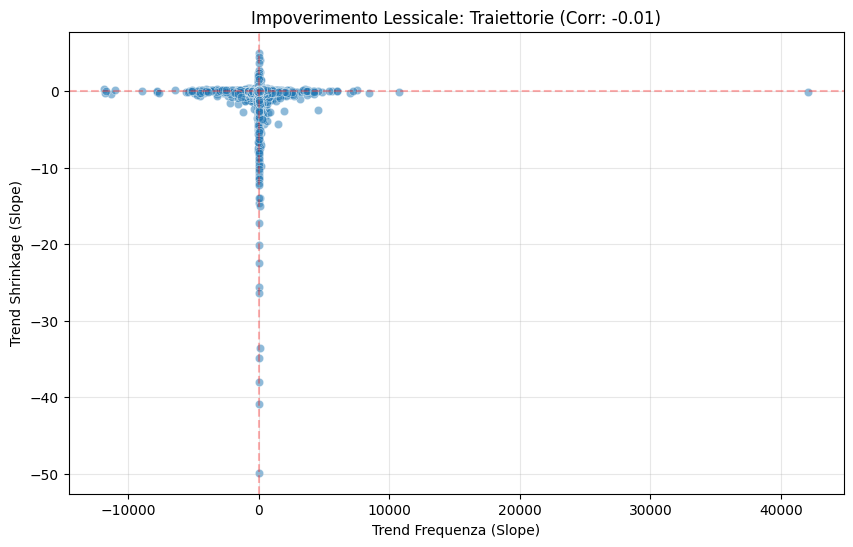

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# --- Caricamento shrinkage + frequenze ---
df_all = pd.read_csv("token_info_filtered_with_complexity_and_slope_norm.csv")

# Assumiamo che df_all contenga sia shrinkage che frequenze
df_shrink = df_all.copy()

results = []

tokens = df_shrink["token"].unique()
snapshots = range(1, 8)  # i tuoi snapshot

for token in tokens:
    row_shrink = df_shrink[df_shrink["token"] == token]
    
    y_shrink = []
    y_freq = []
    x_time = []
    
    for snap in snapshots:
        col_s = f"shrinkage_snap{snap}"
        col_f = f"freq_snap{snap}"
        
        # Recupero valori reali
        val_s = row_shrink[col_s].values[0] if col_s in row_shrink else np.nan
        val_f = df_all.loc[df_all["token"] == token, col_f].values[0] if col_f in df_all else np.nan
        
        if not np.isnan(val_s) and not np.isnan(val_f):
            y_shrink.append(val_s)
            y_freq.append(val_f)
            x_time.append(snap)
    
    if len(x_time) >= 4:  # almeno 4 snapshot validi
        slope_s, _, _, _, _ = linregress(x_time, y_shrink)
        slope_f, _, _, _, _ = linregress(x_time, y_freq)
        
        results.append({
            "token": token,
            "slope_shrinkage": slope_s,
            "slope_frequency": slope_f,
            # puoi aggiungere qui altre categorie se vuoi
        })

df_slopes = pd.DataFrame(results)

# --- 2. Analisi di Correlazione ---
corr = df_slopes["slope_frequency"].corr(df_slopes["slope_shrinkage"])
print(f"Correlazione tra Aumento Frequenza e Aumento Shrinkage: {corr:.4f}")

# --- 3. Visualizzazione (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_slopes, x="slope_frequency", y="slope_shrinkage", alpha=0.5)

# Linee degli assi per dividere i quadranti
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.axvline(0, color='red', linestyle='--', alpha=0.3)

plt.title(f"Impoverimento Lessicale: Traiettorie (Corr: {corr:.2f})")
plt.xlabel("Trend Frequenza (Slope)")
plt.ylabel("Trend Shrinkage (Slope)")
plt.grid(True, alpha=0.3)
plt.show()



In [93]:
# un aumento di frequenza precede una contrazione strutturale?
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

snapshots = range(1, 8)  # 1..7
corr_rows = []

for snap in range(1, 7):  # 1..6 perché guardiamo ΔF(t) vs ΔS(t+1)
    # ΔF: incremento freq t -> t+1
    delta_F = df_all[f"freq_snap{snap+1}"] - df_all[f"freq_snap{snap}"]
    
    # ΔS: incremento shrinkage t -> t+1
    delta_S = df_all[f"shrinkage_snap{snap+1}"] - df_all[f"shrinkage_snap{snap}"]
    
    df_s = pd.DataFrame({
        "delta_F": delta_F,
        "delta_S_next": delta_S
    }).dropna()
    
    # Se ΔF o ΔS sono costanti, skip
    if df_s["delta_F"].std() == 0 or df_s["delta_S_next"].std() == 0:
        continue
    
    # Spearman
    rho, p_rho = spearmanr(df_s["delta_F"], df_s["delta_S_next"])
    # Pearson
    r, p_r = pearsonr(df_s["delta_F"], df_s["delta_S_next"])
    
    corr_rows.append({
        "snap_t": snap,
        "spearman_rho": rho,
        "spearman_p": p_rho,
        "pearson_r": r,
        "pearson_p": p_r,
        "n_tokens": len(df_s)
    })

df_corr_lag = pd.DataFrame(corr_rows)
print(df_corr_lag)


   snap_t  spearman_rho    spearman_p  pearson_r  pearson_p  n_tokens
0       1      0.028429  1.421752e-05  -0.003424   0.601264     23303
1       2     -0.038615  4.048546e-09  -0.006932   0.291136     23190
2       3      0.057553  8.773154e-20  -0.008007   0.205725     24979
3       4      0.073193  7.955838e-33  -0.004892   0.425768     26512
4       5      0.102065  2.042753e-61   0.000968   0.875684     26112
5       6      0.044807  2.564863e-12  -0.005545   0.386591     24382


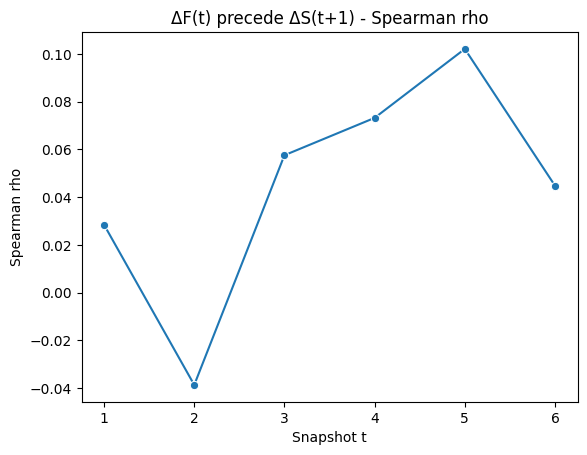

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(x="snap_t", y="spearman_rho", data=df_corr_lag, marker="o")
plt.title("ΔF(t) precede ΔS(t+1) - Spearman rho")
plt.ylabel("Spearman rho")
plt.xlabel("Snapshot t")
plt.show()


In [91]:
# quando la frequenza cambia, lo shrinkage cosa fa?
from scipy.stats import spearmanr

rows = []

for snap in range(1, 7):
    df_s = pd.DataFrame({
        "Si": df_all[f"shrinkage_snap{snap}"],
        "delta_F": df_all[f"freq_snap{snap+1}"] - df_all[f"freq_snap{snap}"]
    }).dropna()

    if df_s["Si"].std() == 0 or df_s["delta_F"].std() == 0:
        continue

    rho, p = spearmanr(df_s["Si"], df_s["delta_F"])

    rows.append({
        "snap": snap,
        "spearman_rho": rho,
        "p_value": p,
        "n_tokens": len(df_s)
    })

df_corr_dyn = pd.DataFrame(rows)
df_corr_dyn


,snap,spearman_rho,p_value,n_tokens
0,2,0.012864,5.055229e-02,23104
1,3,0.037743,2.589491e-09,24885
2,4,0.024620,6.306265e-05,26404
3,5,0.008126,1.900358e-01,26008
4,6,0.010005,1.189329e-01,24288


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import igraph as ig

# --- Percorsi ---
shrink_csv = "semantic_shrinkage_clustering.csv"
freq_dir = Path(r"../embedding/frequencies_all")
sagg_file = Path(r"shrinkage_aggr_cc.csv")
graph_dir = Path(r"networks_hybrid_annotated")
output_csv = "token_cc_info_filtered_with_complexity_and_slope_norm.csv"

snapshots = range(1, 8)

# --- Carico shrinkage ---
df_shrink = pd.read_csv(shrink_csv)

# --- Carico frequenze per tutti gli snapshot ---
freq_dfs = []
for snap in snapshots:
    freq_file = freq_dir / f"vocab_freq_snap{snap}.csv"

    df_freq = pd.read_csv(freq_file)

    df_freq = df_freq.rename(columns={
        "word": "token",
        "frequency": f"freq_snap{snap}"
    })

    df_freq["token"] = df_freq["token"].astype(str)
    df_freq[f"freq_snap{snap}"] = df_freq[f"freq_snap{snap}"].astype(int)

    freq_dfs.append(df_freq)

# --- Merge di tutte le frequenze ---
df_freq_all = freq_dfs[0]
for df_f in freq_dfs[1:]:
    df_freq_all = df_freq_all.merge(df_f, on="token", how="outer")

# --- Filtra token presenti in almeno 5 snapshot ---
appear_count = (df_freq_all.iloc[:, 1:] > 0).sum(axis=1)
df_freq_all = df_freq_all[appear_count >= 5]

# --- Filtra df_shrink per token validi ---
df_shrink = df_shrink[df_shrink["token"].isin(df_freq_all["token"])]

# --- Merge shrinkage + frequenze ---
df_all = df_shrink.merge(df_freq_all, on="token", how="inner")

# --- Aggiungo S_aggregato ---
df_sagg = pd.read_csv(sagg_file)
df_all = df_all.merge(df_sagg, on="token", how="left")

# --- COSTRUISCO COMPLESSITÀ ---
complexity_data = {}

for snap in snapshots:
    graph_file = graph_dir / f"graph_snap{snap}_hybrid.igp"
    G = ig.Graph.Read_Pickle(graph_file)

    for v in G.vs:
        token = v["token"]
        if token not in complexity_data:
            complexity_data[token] = {
                "char_len": v["char_len"],
                "syll_len": v["syll_len"],
                "demauro_level": v["demauro_level"],
                "idf": v["idf"]
            }

# --- Merge complessità ---
df_complexity = (
    pd.DataFrame.from_dict(complexity_data, orient="index")
      .reset_index()
      .rename(columns={"index": "token"})
)
df_all = df_all.merge(df_complexity, on="token", how="left")

# =========================================================
# === CALCOLO ANDAMENTO TEMPORALE DELLA FREQUENZA (ΔF) ===
# =========================================================

freq_cols = [f"freq_snap{snap}" for snap in snapshots]
time = np.array(list(snapshots), dtype=float)

def compute_slope(row):
    y = row[freq_cols].values.astype(float)
    if np.all(y == 0):
        return 0.0
    return np.polyfit(time, y, 1)[0]

df_all["freq_slope"] = df_all.apply(compute_slope, axis=1)
df_all["delta_F"] = df_all["freq_slope"] > 0

# --- Salvataggio finale ---
df_all.to_csv(output_csv, index=False)
print(f"[DONE] CSV completo con complessità e ΔF creato in {output_csv}")


[DONE] CSV completo con complessità e ΔF creato in token_cc_info_filtered_with_complexity_and_slope_norm.csv


Correlazione tra Aumento Frequenza e Aumento Shrinkage: -0.0037


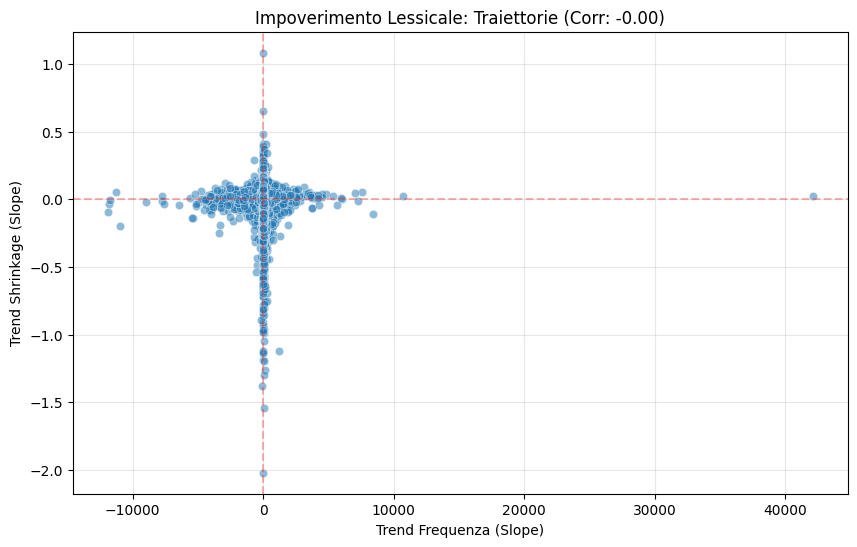

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns

# --- Caricamento shrinkage + frequenze ---
df_all = pd.read_csv("token_cc_info_filtered_with_complexity_and_slope_norm.csv")

# Assumiamo che df_all contenga sia shrinkage che frequenze
df_shrink = df_all.copy()

results = []

tokens = df_shrink["token"].unique()
snapshots = range(1, 8)  # i tuoi snapshot

for token in tokens:
    row_shrink = df_shrink[df_shrink["token"] == token]
    
    y_shrink = []
    y_freq = []
    x_time = []
    
    for snap in snapshots:
        col_s = f"shrinkage_snap{snap}"
        col_f = f"freq_snap{snap}"
        
        # Recupero valori reali
        val_s = row_shrink[col_s].values[0] if col_s in row_shrink else np.nan
        val_f = df_all.loc[df_all["token"] == token, col_f].values[0] if col_f in df_all else np.nan
        
        if not np.isnan(val_s) and not np.isnan(val_f):
            y_shrink.append(val_s)
            y_freq.append(val_f)
            x_time.append(snap)
    
    if len(x_time) >= 4:  # almeno 4 snapshot validi
        slope_s, _, _, _, _ = linregress(x_time, y_shrink)
        slope_f, _, _, _, _ = linregress(x_time, y_freq)
        
        results.append({
            "token": token,
            "slope_shrinkage": slope_s,
            "slope_frequency": slope_f,
            # puoi aggiungere qui altre categorie se vuoi
        })

df_slopes = pd.DataFrame(results)

# --- 2. Analisi di Correlazione ---
corr = df_slopes["slope_frequency"].corr(df_slopes["slope_shrinkage"])
print(f"Correlazione tra Aumento Frequenza e Aumento Shrinkage: {corr:.4f}")

# --- 3. Visualizzazione (Scatter Plot) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_slopes, x="slope_frequency", y="slope_shrinkage", alpha=0.5)

# Linee degli assi per dividere i quadranti
plt.axhline(0, color='red', linestyle='--', alpha=0.3)
plt.axvline(0, color='red', linestyle='--', alpha=0.3)

plt.title(f"Impoverimento Lessicale: Traiettorie (Corr: {corr:.2f})")
plt.xlabel("Trend Frequenza (Slope)")
plt.ylabel("Trend Shrinkage (Slope)")
plt.grid(True, alpha=0.3)
plt.show()



In [87]:
# quando la frequenza cambia, lo shrinkage cosa fa?
from scipy.stats import spearmanr

rows = []

for snap in range(1, 7):
    df_s = pd.DataFrame({
        "Si": df_all[f"shrinkage_snap{snap}"],
        "delta_F": df_all[f"freq_snap{snap+1}"] - df_all[f"freq_snap{snap}"]
    }).dropna()

    if df_s["Si"].std() == 0 or df_s["delta_F"].std() == 0:
        continue

    rho, p = spearmanr(df_s["Si"], df_s["delta_F"])

    rows.append({
        "snap": snap,
        "spearman_rho": rho,
        "p_value": p,
        "n_tokens": len(df_s)
    })

df_corr_dyn = pd.DataFrame(rows)
df_corr_dyn


,snap,spearman_rho,p_value,n_tokens
0,2,0.012864,5.055229e-02,23104
1,3,0.037743,2.589491e-09,24885
2,4,0.024620,6.306265e-05,26404
3,5,0.008126,1.900358e-01,26008
4,6,0.010005,1.189329e-01,24288


Parole più o meno shrinkate

In [57]:
df_all.loc[df_all["delta_F"], ["token", "S_aggregato", "delta_F"]].sort_values(
    "S_aggregato",
    ascending=False
).head(20)


,token,S_aggregato,delta_F
11878,iceberg,0.930625,True
20500,resa,0.790216,True
24644,super,0.776152,True
24173,staff,0.743852,True
19729,puma,0.723938,True
20417,relax,0.713842,True
16706,novità,0.711508,True
23886,spazio,0.707382,True
18922,pre,0.692611,True
21951,salvo,0.676430,True


In [58]:
df_all.loc[df_all["delta_F"], ["token", "S_aggregato", "delta_F"]].sort_values(
    "S_aggregato",
    ascending=True
).head(20)


,token,S_aggregato,delta_F
9306,erminio,-7.878162,True
5817,comma,-6.812352,True
15714,mir,-5.219621,True
3828,bossi,-5.202188,True
25428,tonco,-4.741308,True
910,aldilà,-4.729580,True
9938,fassa,-4.392279,True
8370,distrettuale,-3.788215,True
15217,matassa,-3.638038,True
3721,bollato,-3.277299,True


In [42]:
len(df_all[df_all["delta_F"] == True]) / len(df_all)

0.37612886578937665

In [43]:
len(df_all[df_all["delta_F"] == False]) / len(df_all)

0.6238711342106233

In [44]:
df_all["freq_slope"].describe()


count    20128.000000
mean        -8.658044
std        534.828459
min     -11885.892857
25%        -20.857143
50%          0.375000
75%         23.758929
max      42089.500000
Name: freq_slope, dtype: float64

In [60]:
from scipy.stats import zscore

df_all["S_aggregato_z"] = zscore(df_all["S_aggregato"], nan_policy="omit")
df_all["freq_slope_z"] = zscore(df_all["freq_slope"], nan_policy="omit")

df_all[["S_aggregato_z", "freq_slope_z"]].corr()


,S_aggregato_z,freq_slope_z
S_aggregato_z,1.000000,-0.012202
freq_slope_z,-0.012202,1.000000


In [61]:
df_all["S_aggregato"].corr(
    df_all["freq_slope"],
    method="spearman"
)


-0.07689827804884727

In [59]:
import pandas as pd
import scipy.stats as stats

# --- Definizione eventi ---
df_all["S_positive"] = df_all["S_aggregato"] > 0
df_all["S_negative"] = df_all["S_aggregato"] < 0

# =================================================
# --- Probabilità condizionata delta_F=True / False ---
# =================================================

def cond_prob_stats(event_col):
    p_given_increase = df_all.loc[df_all["delta_F"], event_col].mean()
    p_given_no_increase = df_all.loc[~df_all["delta_F"], event_col].mean()
    p_marginal = df_all[event_col].mean()
    
    lift_f_pos = p_given_increase / p_marginal if p_marginal != 0 else float('nan')
    lift_f_neg = p_given_no_increase / p_marginal if p_marginal != 0 else float('nan')
    relative_risk = (p_given_increase / p_given_no_increase 
                     if p_given_no_increase != 0 else float('nan'))
    
    # Odds Ratio
    odds_inc = p_given_increase / (1 - p_given_increase) if p_given_increase not in [0,1] else float('nan')
    odds_no_inc = p_given_no_increase / (1 - p_given_no_increase) if p_given_no_increase not in [0,1] else float('nan')
    odds_ratio = (odds_inc / odds_no_inc) if (odds_inc not in [float('nan')] and odds_no_inc not in [float('nan')]) else float('nan')
    
    # chi2 test
    ct_raw = pd.crosstab(df_all["delta_F"], df_all[event_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
    
    # tabella condizionata
    ct = pd.crosstab(df_all["delta_F"], df_all[event_col], normalize="index")
    
    return {
        "p_given_increase": p_given_increase,
        "p_given_no_increase": p_given_no_increase,
        "p_marginal": p_marginal,
        "lift_f_pos": lift_f_pos,
        "lift_f_neg": lift_f_neg,
        "relative_risk": relative_risk,
        "odds_ratio": odds_ratio,
        "chi2": chi2,
        "p_value": p_value,
        "contingency_table": ct
    }

# --- Analisi per S_aggregato positivo ---
stats_positive = cond_prob_stats("S_positive")
print("\n=== S_aggregato > 0 ===")
print(stats_positive)

# --- Analisi per S_aggregato negativo ---
stats_negative = cond_prob_stats("S_negative")
print("\n=== S_aggregato < 0 ===")
print(stats_negative)



=== S_aggregato > 0 ===
{'p_given_increase': 0.44899559039686426, 'p_given_no_increase': 0.48934411712615855, 'p_marginal': 0.4741747715885647, 'lift_f_pos': 0.946898943806424, 'lift_f_neg': 1.0319910430636663, 'relative_risk': 0.9175456998108921, 'odds_ratio': 0.8503563696550158, 'chi2': 41.420049836114856, 'p_value': 1.2279149290685054e-10, 'contingency_table': S_positive     False     True 
delta_F                       
False       0.510656  0.489344
True        0.551004  0.448996}

=== S_aggregato < 0 ===
{'p_given_increase': 0.5457128858402743, 'p_given_no_increase': 0.5058740185371037, 'p_marginal': 0.5208517536103743, 'lift_f_pos': 1.0477316857581276, 'lift_f_neg': 0.9712437656791019, 'relative_risk': 1.0787525467672316, 'odds_ratio': 1.1733541285072475, 'chi2': 40.34069557152338, 'p_value': 2.133189327169344e-10, 'contingency_table': S_negative     False     True 
delta_F                       
False       0.494126  0.505874
True        0.454287  0.545713}


# Expand RQ1 with complexity
Analyze the aggregated shrinkage (S_aggr) and the complexity metrics of the tokens.

In [62]:
# --- shrink finale per token
df = df_all.copy()
df["shrink_final"] = df["S_aggregato"] < 0

df_token = (
    df.groupby("token", as_index=False)
      .agg(shrink_final=("shrink_final", "any"),
           S_aggregato=("S_aggregato", "min"))
)

# --- carica CSV De Mauro
token_info = pd.read_csv("token_info_filtered_with_complexity.csv")

token_info = token_info[["token", "demauro_level"]]

# --- merge
df_final = df_token.merge(token_info, on="token", how="left")

# --- conta
df_shrink_final = df_final[df_final["shrink_final"]]

n_shrink_final = len(df_shrink_final)
n_complex_shrink_final = (df_shrink_final["demauro_level"] == 3).sum()

print("Token con S_aggregato < 0:", n_shrink_final)
print("Token complessi (De Mauro = 3):", n_complex_shrink_final)
print("P(complessa | shrink finale):", n_complex_shrink_final / n_shrink_final)


p_complex_base = (token_info["demauro_level"] == 3).mean()
print(p_complex_base)


p_complex_given_shrink = n_complex_shrink_final / n_shrink_final
p_complex_base = (token_info["demauro_level"] == 3).mean()

lift = p_complex_given_shrink / p_complex_base

print("P(complessa | shrink finale):", p_complex_given_shrink)
print("P(complessa) base-rate:", p_complex_base)
print("Lift:", lift)




Token con S_aggregato < 0: 14138
Token complessi (De Mauro = 3): 11141
P(complessa | shrink finale): 0.7880181072287452
0.7723469350141915
P(complessa | shrink finale): 0.7880181072287452
P(complessa) base-rate: 0.7723469350141915
Lift: 1.0202903274475554


In [63]:
import pandas as pd
import scipy.stats as stats

# --- Shrink finale per token ---
df = df_all.copy()
df["shrink_final"] = df["S_aggregato"] < 0

df_token = (
    df.groupby("token", as_index=False)
      .agg(shrink_final=("shrink_final", "any"),
           S_aggregato=("S_aggregato", "min"))
)

# --- Carica CSV De Mauro ---
token_info = pd.read_csv("token_info_filtered_with_complexity.csv")
token_info = token_info[["token", "demauro_level"]]

# --- Merge con De Mauro ---
df_final = df_token.merge(token_info, on="token", how="left")

# --- Definizione evento: complesso De Mauro = 3 ---
df_final["is_complex"] = df_final["demauro_level"] == 3

# =================================================
# --- Funzione per probabilità condizionata ---
# =================================================
def cond_prob_stats(event_col):
    p_given_shrink = df_final.loc[df_final["shrink_final"], event_col].mean()
    p_given_no_shrink = df_final.loc[~df_final["shrink_final"], event_col].mean()
    p_marginal = df_final[event_col].mean()
    
    lift = p_given_shrink / p_marginal if p_marginal != 0 else float('nan')
    relative_risk = (p_given_shrink / p_given_no_shrink 
                     if p_given_no_shrink != 0 else float('nan'))
    
    # Odds Ratio
    odds_shrink = p_given_shrink / (1 - p_given_shrink) if p_given_shrink not in [0,1] else float('nan')
    odds_no_shrink = p_given_no_shrink / (1 - p_given_no_shrink) if p_given_no_shrink not in [0,1] else float('nan')
    odds_ratio = (odds_shrink / odds_no_shrink) if (odds_shrink not in [float('nan')] and odds_no_shrink not in [float('nan')]) else float('nan')
    
    # chi2 test
    ct_raw = pd.crosstab(df_final["shrink_final"], df_final[event_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)
    
    # tabella condizionata
    ct = pd.crosstab(df_final["shrink_final"], df_final[event_col], normalize="index")
    
    return {
        "p_given_shrink": p_given_shrink,
        "p_given_no_shrink": p_given_no_shrink,
        "p_marginal": p_marginal,
        "lift": lift,
        "relative_risk": relative_risk,
        "odds_ratio": odds_ratio,
        "chi2": chi2,
        "p_value": p_value,
        "contingency_table": ct
    }

# --- Analisi complessità De Mauro ---
stats_complex = cond_prob_stats("is_complex")

print("\n=== Analisi De Mauro (complessità livello 3) | shrink finale ===")
print(stats_complex)



=== Analisi De Mauro (complessità livello 3) | shrink finale ===
{'p_given_shrink': 0.7880181072287452, 'p_given_no_shrink': 0.7544210364447178, 'p_marginal': 0.7719201296787503, 'lift': 1.0208544601067657, 'relative_risk': 1.0445335815957053, 'odds_ratio': 1.2100820075409013, 'chi2': 43.240537247724816, 'p_value': 4.8407315381068956e-11, 'contingency_table': is_complex       False     True 
shrink_final                    
False         0.245579  0.754421
True          0.211982  0.788018}


# Weight edge study 

In [21]:
import igraph as ig
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

# Directory dei grafi
graph_dir = Path(r"networks_hybrid")
graph_files = sorted(graph_dir.glob("graph_snap*_hybrid.igp"))

all_weights = []
heavy_edges_info = []

percentile_heavy = 95  # soglia per archi pesanti

print(f"[START] Analisi di {len(graph_files)} snapshot")

for i, gf in enumerate(graph_files, start=1):
    print(f"\n[SNAPSHOT {i}/{len(graph_files)}] Caricamento {gf.name}")
    g = ig.Graph.Read_Pickle(gf)

    if "weight" not in g.es.attribute_names():
        print("Nessun peso sugli archi, salto snapshot")
        continue

    weights = np.array(g.es["weight"])
    all_weights.extend(weights)

    threshold = np.percentile(weights, percentile_heavy)
    heavy_edges = [e.index for e in g.es if e["weight"] >= threshold]

    print(f"Totale archi: {g.ecount()}, archi pesanti (> {percentile_heavy}° percentile): {len(heavy_edges)}")

    for e_idx in heavy_edges:
        e = g.es[e_idx]
        src, dst = e.tuple
        heavy_edges_info.append({
            "snapshot": gf.stem,
            "source": g.vs[src]["token"],
            "target": g.vs[dst]["token"],
            "weight": e["weight"]
        })

print("\n[END] Analisi completata su tutti gli snapshot")



# # ---------- Archi pesanti ----------
# df_heavy = pd.DataFrame(heavy_edges_info)
# print("\nTop 20 archi più pesanti:")
# print(df_heavy.sort_values("weight", ascending=False).head(20))


[START] Analisi di 7 snapshot

[SNAPSHOT 1/7] Caricamento graph_snap1_hybrid.igp
Totale archi: 3033079, archi pesanti (> 95° percentile): 151654

[SNAPSHOT 2/7] Caricamento graph_snap2_hybrid.igp
Totale archi: 1985640, archi pesanti (> 95° percentile): 99282

[SNAPSHOT 3/7] Caricamento graph_snap3_hybrid.igp
Totale archi: 1930980, archi pesanti (> 95° percentile): 96550

[SNAPSHOT 4/7] Caricamento graph_snap4_hybrid.igp
Totale archi: 3011365, archi pesanti (> 95° percentile): 150569

[SNAPSHOT 5/7] Caricamento graph_snap5_hybrid.igp
Totale archi: 3482725, archi pesanti (> 95° percentile): 174137

[SNAPSHOT 6/7] Caricamento graph_snap6_hybrid.igp
Totale archi: 3604324, archi pesanti (> 95° percentile): 180220

[SNAPSHOT 7/7] Caricamento graph_snap7_hybrid.igp
Totale archi: 2390413, archi pesanti (> 95° percentile): 119522

[END] Analisi completata su tutti gli snapshot


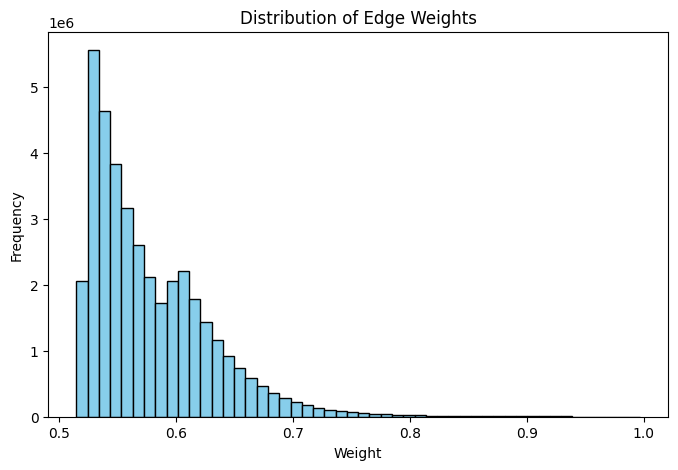

In [ ]:
all_weights = np.array(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()


<Figure size 1600x600 with 0 Axes>

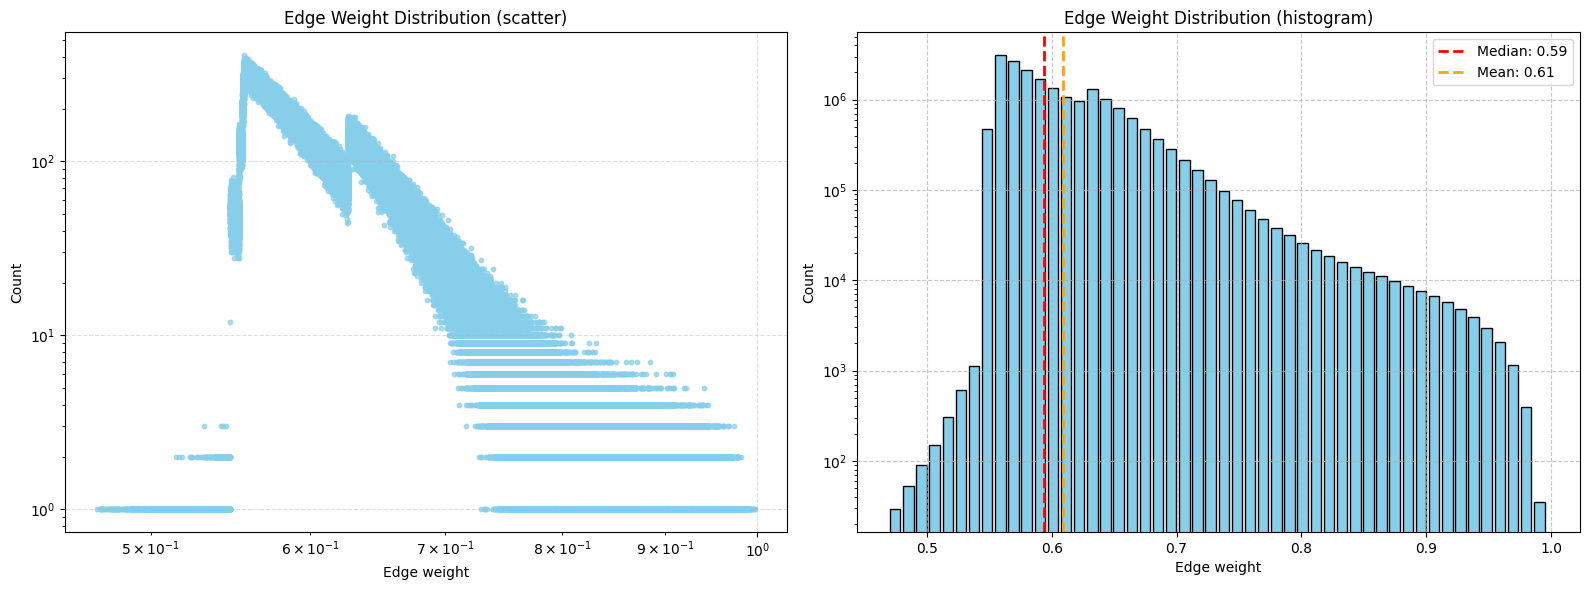

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Supponiamo che all_weights sia già un array numpy
all_weights = np.array(all_weights)

# Contiamo la frequenza di ogni peso
unique_weights, counts = np.unique(all_weights, return_counts=True)

# Histogram bins simili a quelli usati per i gradi
bin_width = (all_weights.max() - all_weights.min()) / 50  # 50 bins
bins = np.arange(all_weights.min(), all_weights.max() + bin_width, bin_width)

plt.figure(figsize=(16,6))
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# --- Scatter plot ---
axes[0].scatter(unique_weights, counts, alpha=0.7, s=10, color='skyblue')
axes[0].set_xlabel("Edge weight")
axes[0].set_ylabel("Count")
axes[0].set_title("Edge Weight Distribution (scatter)")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.4)

# --- Histogram ---
axes[1].hist(all_weights, bins=bins, color='skyblue', edgecolor='black', width=bin_width*0.8)
median_weight = np.median(all_weights)
mean_weight = np.mean(all_weights)

axes[1].axvline(median_weight, color='red', linestyle='--', linewidth=2, label=f"Median: {median_weight:.2f}")
axes[1].axvline(mean_weight, color='orange', linestyle='--', linewidth=2, label=f"Mean: {mean_weight:.2f}")

axes[1].set_xlabel("Edge weight")
axes[1].set_ylabel("Count")
axes[1].set_title("Edge Weight Distribution (histogram)")
axes[1].set_yscale("log")
axes[1].grid(True, linestyle="--", alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


In [23]:
# Mostrare tutte le righe senza troncamento
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)  # larghezza del terminale
pd.set_option("display.max_colwidth", None)

# ---------- Archi pesanti ----------
df_heavy = pd.DataFrame(heavy_edges_info)
print("\nTop 300 archi più pesanti:")
print(df_heavy.sort_values("weight", ascending=False).head(300))



Top 300 archi più pesanti:
                  snapshot                source               target    weight
527897  graph_snap5_hybrid              mmmmmmmm              mmmmmmm  0.996928
606002  graph_snap5_hybrid                mmmmmm              mmmmmmm  0.996261
596701  graph_snap5_hybrid    fondicriinternazre     fondicriinternaz  0.995070
133820  graph_snap1_hybrid    autoferrotranviero   autoferrotranviere  0.995024
733297  graph_snap6_hybrid        teatridithalia       teatridithalio  0.994066
431289  graph_snap4_hybrid    autoferrotranviero   autoferrotranviere  0.993182
325587  graph_snap3_hybrid    autoferrotranviero   autoferrotranviere  0.992464
153819  graph_snap2_hybrid    autoferrotranviero   autoferrotranviere  0.991648
588333  graph_snap5_hybrid         antimeridiana        antimeridiano  0.991603
552848  graph_snap5_hybrid           capitalgest           capitalges  0.991446
498310  graph_snap5_hybrid         phenixfundtop           phenixfund  0.991311
3469    grap